# $\lambda$-return and TD($\lambda$)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class RandomWalk:
    def __init__(self, num_states=19):
        self.num_states = num_states
        self.start_state = self.num_states // 2
        self.current_state = None

    def reset(self):
        self.current_state = self.start_state
        return {'state':self.current_state}

    def is_terminal(self):
        return self.current_state == 0 or self.current_state == self.num_states - 1

    def step(self, action):
        if self.is_terminal():
            return {'state':self.current_state, 'reward':0.0}

        if action == 0:
            self.current_state -= 1
        else:
            self.current_state += 1

        if self.current_state == 0:
            reward = -1.0
        elif self.current_state == self.num_states - 1:
            reward = 1.0
        else:
            reward = 0.0
        return {'state':self.current_state, 'reward':reward}


In [3]:
feature_vectors = np.eye(21, 21, 0)

In [4]:
def rms(w:np.ndarray, v_star:np.ndarray):
    v = w.T@feature_vectors
    return np.sqrt(np.mean((v[1:-1] - v_star[1:-1]) ** 2))

## Off-line $\lambda$-return algorithm

In [8]:
def offline_lambda(
    env,
    w:np.ndarray,
    episodes:int,
    alpha:float,
    lambda_:float,
    gamma:float=1.0,
):
    w = w.copy()
    for _ in range(episodes):
        state = env.reset()['state']
        trajectory = [{'state':state}]
        while not env.is_terminal():
            action = np.random.choice(2)
            feedback = env.step(action)
            trajectory.append(feedback)

        states = np.array([x['state'] for x in trajectory], dtype=np.int32)
        rewards = np.array([x.get('reward', 0.0) for x in trajectory])

        T = len(trajectory)
        g_lambda = np.zeros(T)
        for t in range(T - 1):
            g_t_lambda = 0
            for n in range(1, T - t):
                discounts = gamma ** np.arange(n)
                g_t_n = np.sum(discounts * rewards[t+1:t+n+1])

                if t + n < T - 1:
                    g_t_n += gamma ** n * (w.T @ feature_vectors[states[t + n]])
                
                g_t_lambda += lambda_ ** (n - 1) * g_t_n

            g_t_lambda = (1 - lambda_) * g_t_lambda

            discounts = gamma ** np.arange(T - t - 1)
            g_t_terminal = np.sum(discounts * rewards[t+1:])
            g_t_terminal *= lambda_ ** (T - t - 1)

            g_t_lambda += g_t_terminal

            g_lambda[t] = g_t_lambda

        
            
        for t in range(T - 1):
            if states[t] == 0 or states[t] == 20:
                continue
            x_t = feature_vectors[states[t]]
            w = w + alpha * (g_lambda[t] - w.T@x_t) * x_t
    return w

In [9]:
def offline_gamma_return_experiment(
    alpha:float,
    lambda_:float,
    episodes:int=10,
    runs:int=100,
    num_states:int=21
):
    env = RandomWalk(num_states=num_states)
    w_init = np.zeros(num_states, dtype=np.float32)
    w_init[0] = 0.0
    w_init[-1] = 0.0
    
    v_star = np.linspace(-1, 1, num=num_states, dtype=np.float32)
    v_star[-1] = 0
    v_star[0] = 0
    res = 0
    for r in range(runs):
        w = offline_lambda(
            env=env,
            w=w_init,
            episodes=episodes,
            alpha=alpha,
            lambda_=lambda_
        )
        res += rms(w, v_star)
    return res / runs

In [10]:
def run_experiment_for_alpha(experiment:callable, lambda_, runs, episodes, alphas):
    print("running for", lambda_)
    results = []
    for alpha in alphas:
        res = experiment(lambda_=lambda_, alpha=alpha, runs=runs, episodes=episodes)
        results.append(res)
        print(alpha, 'done')
    return results

In [11]:
lambdas = [0.0, 0.4, 0.8, 0.9, 0.95, 0.975, 0.99, 1.0]
alphas = np.linspace(0.00, 1.00, 21)

lambda_rms = []

for idx, lambda_ in enumerate(lambdas):
        result = run_experiment_for_alpha (
            experiment=offline_gamma_return_experiment,
            lambda_=lambda_,
            runs=30,
            episodes=10,
            alphas=alphas
        )
        lambda_rms.append(result)

running for 0.0
0.0 done
0.05 done
0.1 done
0.15000000000000002 done
0.2 done
0.25 done
0.30000000000000004 done
0.35000000000000003 done
0.4 done
0.45 done
0.5 done
0.55 done
0.6000000000000001 done
0.65 done
0.7000000000000001 done
0.75 done
0.8 done
0.8500000000000001 done
0.9 done
0.9500000000000001 done
1.0 done
running for 0.4
0.0 done
0.05 done
0.1 done
0.15000000000000002 done
0.2 done
0.25 done
0.30000000000000004 done
0.35000000000000003 done
0.4 done
0.45 done
0.5 done
0.55 done
0.6000000000000001 done
0.65 done
0.7000000000000001 done
0.75 done
0.8 done
0.8500000000000001 done
0.9 done
0.9500000000000001 done
1.0 done
running for 0.8
0.0 done
0.05 done
0.1 done
0.15000000000000002 done
0.2 done
0.25 done
0.30000000000000004 done
0.35000000000000003 done
0.4 done
0.45 done
0.5 done
0.55 done
0.6000000000000001 done
0.65 done
0.7000000000000001 done
0.75 done
0.8 done
0.8500000000000001 done
0.9 done
0.9500000000000001 done
1.0 done
running for 0.9
0.0 done
0.05 done
0.1 done

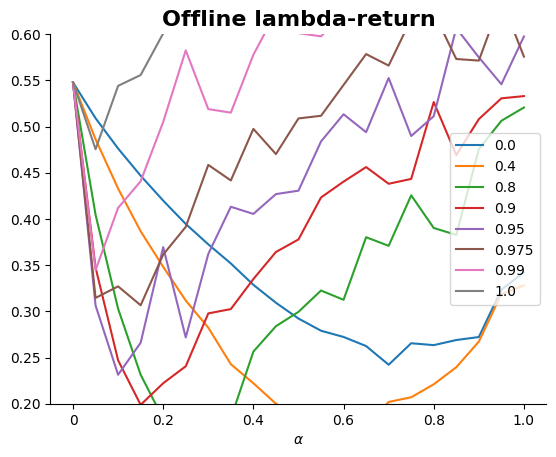

In [12]:
fig = plt.figure()
ax = plt.subplot(111)

title = "Offline lambda-return"

for i, k in enumerate(lambda_rms):
    ax.plot(alphas, k, label=lambdas[i])

ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0]);
ax.set_xticklabels([0, 0.2, 0.4, 0.6, 0.8, 1.0]);
ax.set_ylim([0.2, 0.6])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel(r"$\alpha$");
ax.set_title(title, fontdict={'fontsize':16, 'fontweight':1000});
ax.legend()

## TD($\lambda$)

In [13]:
def td_lambda(
    env:RandomWalk,
    w:np.ndarray,
    alpha:float,
    lambda_:float,
    episodes:int,
    gamma:float=1.0,
):
    w = w.copy()

    for episode in range(episodes):
        state = env.reset()['state']
        z = np.zeros_like(w)

        while not env.is_terminal():
            action = np.random.choice(2)
            feedback = env.step(action)
            next_state = feedback['state']
            reward = feedback['reward']

            x_state = feature_vectors[state]
            x_next_state = feature_vectors[next_state]
            if env.is_terminal():
                v_next_state = 0.0
            else:
                v_next_state = w.T@x_next_state
            
            z = gamma * lambda_ * z + x_state
            delta = reward + gamma * v_next_state - w.T@x_state
            w = w + alpha * delta * z

            state = next_state

    return w

In [14]:
def td_lambda_experiment(
    alpha:float,
    lambda_:float,
    episodes:int=100,
    runs:int=100,
    num_states:int=21
):
    env = RandomWalk(num_states=num_states)
    w_init = np.zeros(num_states, dtype=np.float32)
    w_init[0] = 0.0
    w_init[-1] = 0.0
    
    v_star = np.linspace(-1, 1, num_states, dtype=np.float32)
    v_star[-1] = 0
    v_star[0] = 0
    res = 0
    for r in range(runs):
        w = td_lambda(
            env=env,
            w=w_init,
            episodes=episodes,
            alpha=alpha,
            lambda_=lambda_
        )

        res += rms(w, v_star)
    return res / runs

In [15]:
lambdas = [0.0, 0.4, 0.8, 0.9, 0.95, 0.975, 0.99, 1.0]
alphas = np.linspace(0.00, 1.00, 21)

lambda_rms = []

for idx, lambda_ in enumerate(lambdas):
        result = run_experiment_for_alpha (
            experiment=td_lambda_experiment,
            lambda_=lambda_,
            runs=50,
            episodes=10,
            alphas=alphas
        )
        lambda_rms.append(result)

running for 0.0
0.0 done
0.05 done
0.1 done
0.15000000000000002 done
0.2 done
0.25 done
0.30000000000000004 done
0.35000000000000003 done
0.4 done
0.45 done
0.5 done
0.55 done
0.6000000000000001 done
0.65 done
0.7000000000000001 done
0.75 done
0.8 done
0.8500000000000001 done
0.9 done
0.9500000000000001 done
1.0 done
running for 0.4
0.0 done
0.05 done
0.1 done
0.15000000000000002 done
0.2 done
0.25 done
0.30000000000000004 done
0.35000000000000003 done
0.4 done
0.45 done
0.5 done
0.55 done
0.6000000000000001 done
0.65 done
0.7000000000000001 done
0.75 done
0.8 done
0.8500000000000001 done
0.9 done
0.9500000000000001 done
1.0 done
running for 0.8
0.0 done
0.05 done
0.1 done
0.15000000000000002 done
0.2 done
0.25 done
0.30000000000000004 done
0.35000000000000003 done
0.4 done
0.45 done
0.5 done
0.55 done
0.6000000000000001 done
0.65 done
0.7000000000000001 done
0.75 done
0.8 done
0.8500000000000001 done
0.9 done
0.9500000000000001 done
1.0 done
running for 0.9
0.0 done
0.05 done
0.1 done

/tmp/ipykernel_6613/4167402940.py:3: RuntimeWarning: overflow encountered in square
  return np.sqrt(np.mean((v[1:-1] - v_star[1:-1]) ** 2))


0.9 done


/home/alireza/miniconda3/envs/torch/lib/python3.13/site-packages/numpy/_core/_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


0.9500000000000001 done
1.0 done
running for 0.99
0.0 done
0.05 done
0.1 done
0.15000000000000002 done
0.2 done
0.25 done
0.30000000000000004 done
0.35000000000000003 done
0.4 done
0.45 done
0.5 done
0.55 done
0.6000000000000001 done
0.65 done
0.7000000000000001 done
0.75 done
0.8 done


/tmp/ipykernel_6613/1652646302.py:30: RuntimeWarning: overflow encountered in multiply
  w = w + alpha * delta * z
/tmp/ipykernel_6613/1652646302.py:30: RuntimeWarning: overflow encountered in add
  w = w + alpha * delta * z
/tmp/ipykernel_6613/1652646302.py:26: RuntimeWarning: invalid value encountered in matmul
  v_next_state = w.T@x_next_state
/tmp/ipykernel_6613/1652646302.py:29: RuntimeWarning: invalid value encountered in matmul
  delta = reward + gamma * v_next_state - w.T@x_state


0.8500000000000001 done
0.9 done
0.9500000000000001 done
1.0 done
running for 1.0
0.0 done
0.05 done
0.1 done
0.15000000000000002 done
0.2 done
0.25 done
0.30000000000000004 done
0.35000000000000003 done
0.4 done
0.45 done
0.5 done
0.55 done
0.6000000000000001 done
0.65 done
0.7000000000000001 done
0.75 done
0.8 done
0.8500000000000001 done
0.9 done
0.9500000000000001 done
1.0 done


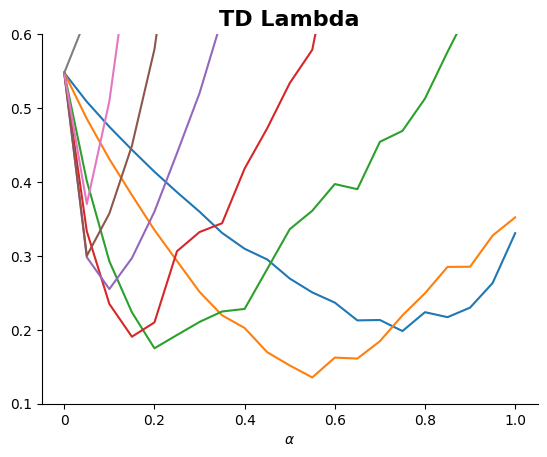

In [16]:
fig = plt.figure()
ax = plt.subplot(111)

title = "TD Lambda"

for k in lambda_rms:
    ax.plot(alphas, k)

ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0]);
ax.set_xticklabels([0, 0.2, 0.4, 0.6, 0.8, 1.0]);
ax.set_ylim([0.1, 0.6])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel(r"$\alpha$");
ax.set_title(title, fontdict={'fontsize':16, 'fontweight':1000});